# Phase 0 — Data Exploration
Goal: understand the shape of the data before building anything.
Nothing here should be reused by model code — notebooks are for understanding, not production logic.

In [21]:
import sys
sys.path.insert(0, '..')  # make `src` importable from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
from src.data.load import load_ratings, load_movies

In [22]:
ratings = load_ratings()
movies = load_movies()
print(ratings.shape)
ratings.head()

(100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Sparsity
The user-item matrix has `n_users × n_movies` cells. Most are empty — that's the core challenge of collaborative filtering.

In [23]:
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f'Users:    {n_users}')
print(f'Movies:   {n_movies}')
print(f'Ratings:  {n_ratings}')
print(f'Sparsity: {sparsity:.2%}')  # expect ~93-94%

Users:    943
Movies:   1682
Ratings:  100000
Sparsity: 93.70%


## Rating Distribution
Are ratings skewed? A model that always predicts 4 might look good just because most ratings are 4.

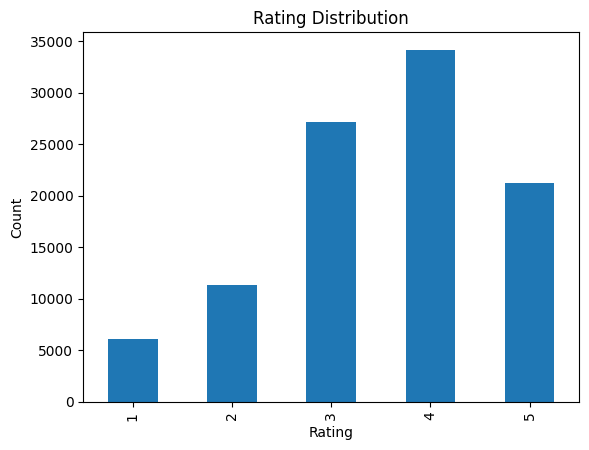

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [24]:
ratings['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()
ratings['rating'].describe()

## Ratings per User
A few power-users rate hundreds of movies; most rate far fewer. This long tail matters for cold-start.

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


AttributeError: Rectangle.set() got an unexpected keyword argument 'title'

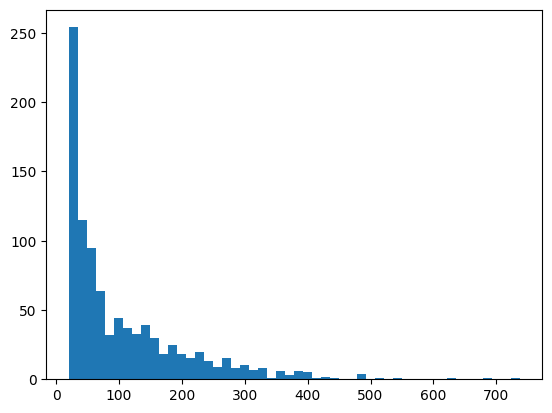

In [25]:
ratings_per_user = ratings.groupby('user_id').size()
print(ratings_per_user.describe())
ratings_per_user.hist(bins=50, title='Ratings per User')
plt.xlabel('# Ratings')
plt.ylabel('# Users')
plt.show()

## Ratings per Movie
Popular movies get rated a lot; most movies are rarely rated. Item-item CF struggles with obscure movies.

count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64


AttributeError: Rectangle.set() got an unexpected keyword argument 'title'

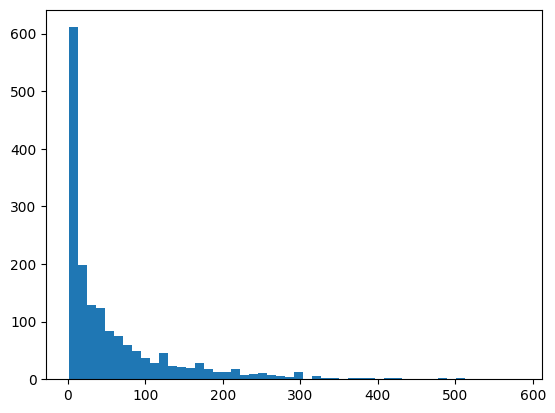

In [26]:
ratings_per_movie = ratings.groupby('movie_id').size()
print(ratings_per_movie.describe())
ratings_per_movie.hist(bins=50, title='Ratings per Movie')
plt.xlabel('# Ratings')
plt.ylabel('# Movies')
plt.show()

## Train/Test Split — quick sanity check

In [19]:
from src.data.split import train_test_split

train, test = train_test_split(ratings)
print(f'Train rows: {len(train)}')
print(f'Test rows:  {len(test)}')
print(f'Train users: {train["user_id"].nunique()}')
print(f'Test users:  {test["user_id"].nunique()}')
print(f'All test users in train: {set(test["user_id"]).issubset(set(train["user_id"]))}')

Train rows: 80000
Test rows:  20000
Train users: 943
Test users:  943
All test users in train: True
